### **Ways of Testing if Models Satisfy Assumptions for Linear Regression**
Assumptions:
1. Linearity - assuming the relationship between the independent variable and dependent variable is linear
2. Independence of Residuals - if two variables have a linear relationship, then their residuals (distances of the points from the regression line) should be random.
3. Homoscedasticity - condition where the variance of the residuals is constant across all levels of the independent variable (x-axis).
4. Normality of Residuals - if two variables have a linear relationship, the values of their residuals should follow a normal distribution.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro

In [2]:
### generate random sample data from a normal distribution
rg = np.random.default_rng(seed=33)
x = rg.normal(5, 1, (500, 1))
noise = rg.normal(0, 1, (500, 1))
y = 3 + (4/5)*x + noise

df = pd.DataFrame({
    'x': x.flatten(),
    'y': y.flatten()
})
df.head()

,x,y
0,5.398370,8.611517
1,4.437177,8.814345
2,5.588835,8.572306
3,5.042118,7.421977
4,3.429099,6.298654


In [3]:
### fit a OLS simple linear regression model
x = df['x']
x_with_const = sm.add_constant(x)
y = df['y']
model = sm.OLS(y, x_with_const)
results = model.fit()
residuals = results.resid
fitted_values = results.fittedvalues
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.340
Model:                            OLS   Adj. R-squared:                  0.339
Method:                 Least Squares   F-statistic:                     256.7
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           6.71e-47
Time:                        20:00:55   Log-Likelihood:                -719.57
No. Observations:                 500   AIC:                             1443.
Df Residuals:                     498   BIC:                             1452.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1249      0.247     12.646      0.000       2.639       3.610
x              0.7720      0.048     16.023      0.000       0.677       0.867
==============================================================================
Omnibus:                        3.925   Durbin-Watson:                   1.875
Prob(Omnibus):                  0.140   Jarque-Bera (JB):                2.929
Skew:                          -0.008   Prob(JB):                        0.231
Kurtosis:                       2.625   Cond. No.                         28.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### **1. Linearity**
* Visually inpect the relationship between x and y and look for a general linearity of the data

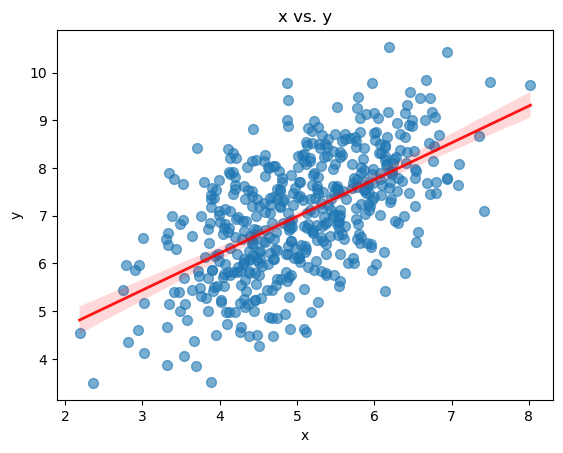

In [4]:
sns.regplot(
    data=df,
    x="x",
    y="y",
    scatter_kws={
        #"color": "blue",
        "alpha": 0.6,
        "s": 50,
    },
    line_kws={
        "color": "red",
        "alpha": 0.9,
        "linewidth": 2,
    },
)
plt.title('x vs. y')
plt.show()

#### **2. Independence of Residuals**
* A plot of the residuals over time should show no pattern emerging.
* The Durbin-Watson test can be used to find autocorrelation between residuals. If they are correlated, the standard errors of the coefficients can be underestimated, resulting in misleading inferences:
  - (0 - 1) = strong positive autocorrelation
  - ( < 2 ) = positive autocorrelation
  - ( 2 ) = no autocorrelation
  - ( > 2 ) = negative autocorrelation
  - (3 - 4) = strong negative autocorrelation

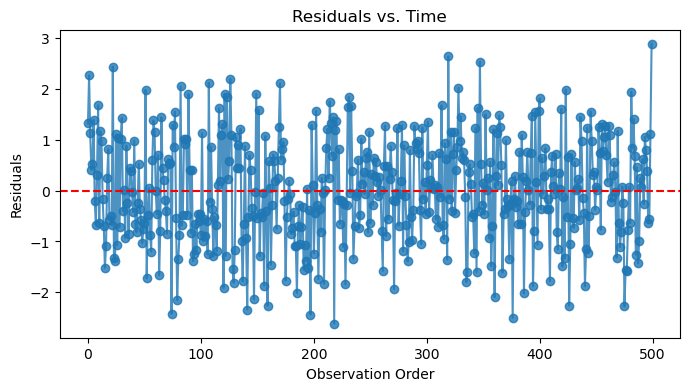

In [5]:
### plot residuals over time
plt.figure(figsize=(8, 4))
plt.plot(residuals, marker='o', alpha=0.8)
plt.title('Residuals vs. Time')
plt.xlabel('Observation Order')
plt.ylabel('Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [6]:
### The Durbin-Watson Test
dw = durbin_watson(residuals)
print(f'Durbin-Watson Statistic: {dw:.3f}')

Durbin-Watson Statistic: 1.875


#### **3. Homoscedasticity**
* A residuals vs fitted plot should show consistent spread and randomnness
* A funnel shape would indicate heteroscedasticity = violation of assumption

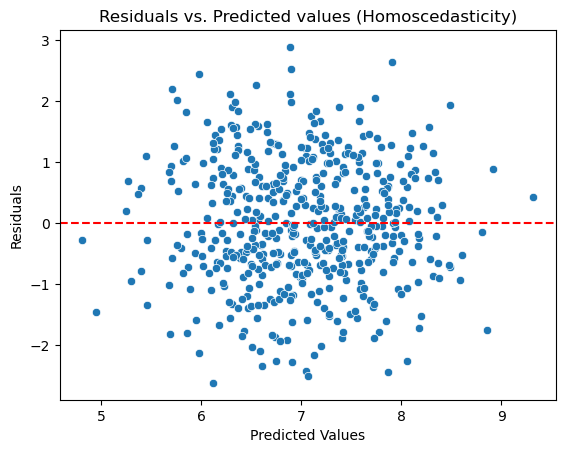

In [7]:
### residuals vs. fitted values
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(0, linestyle='--', color='red')
plt.title('Residuals vs. Predicted values (Homoscedasticity)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

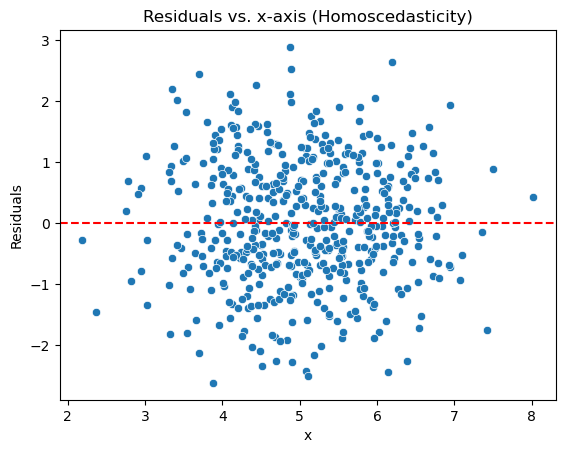

In [8]:
### residual vs. x-axis
sns.scatterplot(x=x, y=residuals)
plt.axhline(0, linestyle='--', color='red')
plt.title('Residuals vs. x-axis (Homoscedasticity)')
plt.xlabel('x')
plt.ylabel('Residuals')
plt.show()

#### **4. Normality of Residuals**
* A simple histogram quickly shows the shape of the distribution
* A Quantile-Quantile Plot: quantiles of your data on y-axis, quanitiles of a theoretical distribution on x-axis
  - points lie on line = data follows distribution
  - points curve up or down = skewness (right or left)
  - points deviate at ends = heavy or light tailed distributions
  - individual points far off of line = outliers
* The Shapiro-Wilk Test; recommended for n<=50 but is usable up to approximately 2000 observations
  - if p-value is less than your chosen significance level = data is likely not normal
  - if p-value is high = suggest the data may be normal

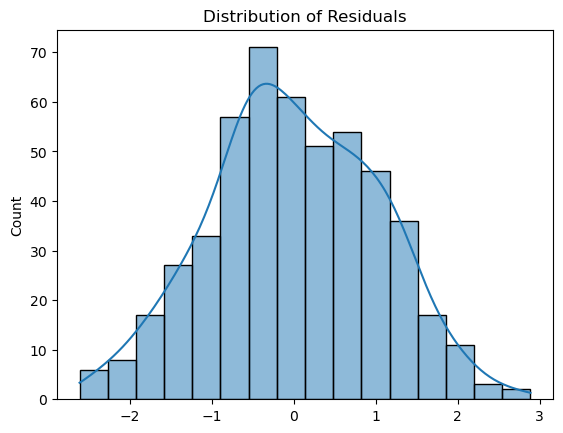

In [9]:
### histogram of residuals to observe a bell-shape distribution
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.show()

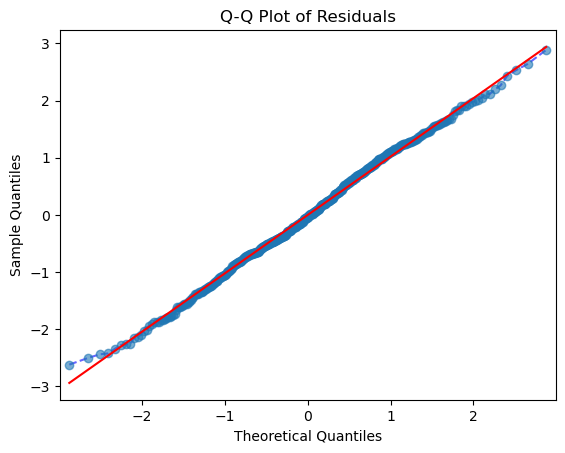

In [10]:
### statsmodels Q-Q Plot
fig = sm.qqplot(residuals, line='s', linestyle='--', alpha=0.6)
plt.title('Q-Q Plot of Residuals')
plt.show()

In [11]:
### The Shapiro-Wilk Test
stat, p = shapiro(residuals)
print(f'Shapiro-Wilk Test:\nStatistic = {stat:.3f}\nP-value = {p:.3f}')

Shapiro-Wilk Test:
Statistic = 0.996
P-value = 0.301
